# Bike and Car Classification (ComVis)

# i. Introduction

Nama  : Hafizal Shakur

**Objective:**

Melakukan deteksi dan klasifikasi dalam bidang Computer Vision terhadap objek Bike atau Car menggunakan model Convolutional Neural Network yang merupakan salah satu model Neural Network sesuai dengan bidang tersebut. Penentuan kelas kendaraan tersebut digunakan untuk memberikan jasa pelayanan terhadap pengelola parkir, yaitu berupa:
- Melakukan penyesuaian terhadap kapasitas parkir motor dan mobil
- Mendeteksi ketersediaan lahan parkir berdasarkan jumlah kendaraan dari gate masuk
- Menerapkan sistem otomatisasi dalam menentukan tarif parkir pada gate masuk dan keluar

# ii. Import Libraries

In [ ]:
# !pip install -q --upgrade "tensorflow<2.16" "tf-keras<2.16"

In [ ]:
# import libraries

# from google.colab import files
from google.colab import drive
import os
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import pandas as pd
import numpy as np
import glob
from sklearn.model_selection import train_test_split
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
print(tf.__version__)

2.18.0


# iii. Data Loading


Dataset yang saya gunakan didapat dari website [Kaggle](https://www.kaggle.com/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset). Data tersebut kemudian saya simpan ke dalam Google Drive agar lebih mudah dalam memuatnya kembali. Data juga di-compress dalam bentuk zip agar ukuran file tidak terlalu besar.

In [ ]:
# upload file json untuk mengambil dataset kaggle

# files.upload()

In [ ]:
# menginstall kaggle

# !pip install -q kaggle

In [ ]:
# download dataset dari kaggle

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# !kaggle datasets download -d utkarshsaxenadn/car-vs-bike-classification-dataset

# !unzip car-vs-bike-classification-dataset.zip

In [ ]:
# mengakses google drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# membuat folder untuk menyimpan dataset

# os.makedirs("/content/drive/My Drive/kaggle_data", exist_ok=True)

In [ ]:
# menyimpan dataset ke google drive

# !cp car-vs-bike-classification-dataset.zip "/content/drive/My Drive/kaggle_data/"

In [ ]:
# memuat data dari drive ke colab

!cp "/content/drive/My Drive/kaggle_data/car-vs-bike-classification-dataset.zip" /content/

In [ ]:
# mengesktrak data dari file zip
!unzip car-vs-bike-classification-dataset.zip

Archive:  car-vs-bike-classification-dataset.zip
  inflating: Car-Bike-Dataset/Bike/Bike (1).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1).jpg  
  inflating: Car-Bike-Dataset/Bike/Bike (1).png  
  inflating: Car-Bike-Dataset/Bike/Bike (10).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (10).jpg  
  inflating: Car-Bike-Dataset/Bike/Bike (10).png  
  inflating: Car-Bike-Dataset/Bike/Bike (100).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (100).jpg  
  inflating: Car-Bike-Dataset/Bike/Bike (1000).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1001).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1002).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1003).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1004).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1005).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1006).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1007).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1008).jpeg  
  inflating: Car-Bike-Dataset/Bike/Bike (1009).jpeg  
 

In [ ]:
# menampilkan file data bike
!ls /content/Car-Bike-Dataset/Bike

'Bike (1000).jpeg'  'Bike (1327).jpeg'	'Bike (181).jpg'   'Bike (4).jpg'     'Bike (828).jpeg'
'Bike (1001).jpeg'  'Bike (1328).jpeg'	'Bike (182).jpeg'  'Bike (4).png'     'Bike (829).jpeg'
'Bike (1002).jpeg'  'Bike (1329).jpeg'	'Bike (182).jpg'   'Bike (500).jpeg'  'Bike (82).jpeg'
'Bike (1003).jpeg'  'Bike (132).jpeg'	'Bike (183).jpeg'  'Bike (501).jpeg'  'Bike (82).jpg'
'Bike (1004).jpeg'  'Bike (132).jpg'	'Bike (183).jpg'   'Bike (502).jpeg'  'Bike (830).jpeg'
'Bike (1005).jpeg'  'Bike (1330).jpeg'	'Bike (184).jpeg'  'Bike (503).jpeg'  'Bike (831).jpeg'
'Bike (1006).jpeg'  'Bike (1331).jpeg'	'Bike (184).jpg'   'Bike (504).jpeg'  'Bike (832).jpeg'
'Bike (1007).jpeg'  'Bike (1332).jpeg'	'Bike (185).jpeg'  'Bike (505).jpeg'  'Bike (833).jpeg'
'Bike (1008).jpeg'  'Bike (1333).jpeg'	'Bike (185).jpg'   'Bike (506).jpeg'  'Bike (834).jpeg'
'Bike (1009).jpeg'  'Bike (1334).jpeg'	'Bike (186).jpeg'  'Bike (507).jpeg'  'Bike (835).jpeg'
'Bike (100).jpeg'   'Bike (1335).jpeg'	'Bike (186).jpg' 

Terlihat proses pengambilan dan ekstraksi data dari Google Drive berhasil dilakukan. Selanjutnya adalah proses eksplorasi analisis data untuk

# iv. Exploratory Data Analysis

### 1. Jumlah dan Tipe File Gambar

In [ ]:
dataset_path = '/content/Car-Bike-Dataset'

# mengumpulkan file
file_paths = glob.glob(f'{dataset_path}/**/*.*', recursive=True)
file_types = set([os.path.splitext(file)[1].lower() for file in file_paths])  # mengekstrak ekstensi file
print(f'File types in the dataset: {file_types}')


File types in the dataset: {'.png', '.jpeg', '.jpg'}


In [ ]:
# menghitung jumlah tiap file
file_count = Counter()
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        file_count[ext] += 1

print(f'File type counts: {file_count}')


File type counts: Counter({'.jpeg': 3731, '.jpg': 239, '.png': 30})


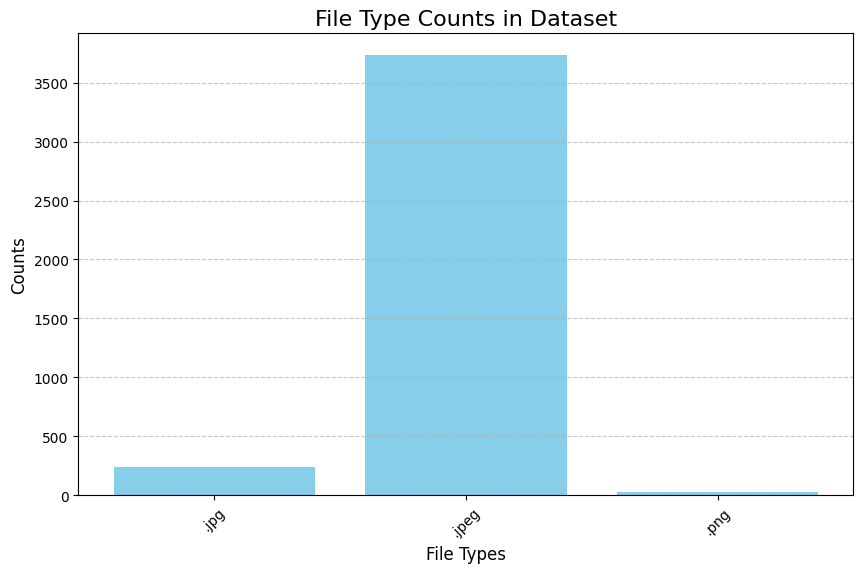

In [ ]:
# visualisasi jumlah tiap file
extensions = list(file_count.keys())
counts = list(file_count.values())

plt.figure(figsize=(10, 6))
plt.bar(extensions, counts, color='skyblue')
plt.xlabel('File Types', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.title('File Type Counts in Dataset', fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Ditemukan bahwa terdapat tipe file yang berbeda dari dataset yang didapatkan dengan ekstensi .jpeg,.jpg, dan .png, dengan masing-masing sebanyak 3731, 239, dan 30. Saya memutuskan untuk tidak mengubah tipe file menjadi seragam karena library seperti tensorflow mampu melaksanakan proses training dengan tipe file yang berbeda.

### 2. Distribusi Data tiap Kelas

Category Distribution:
Bike: 1999 images
Car: 1997 images


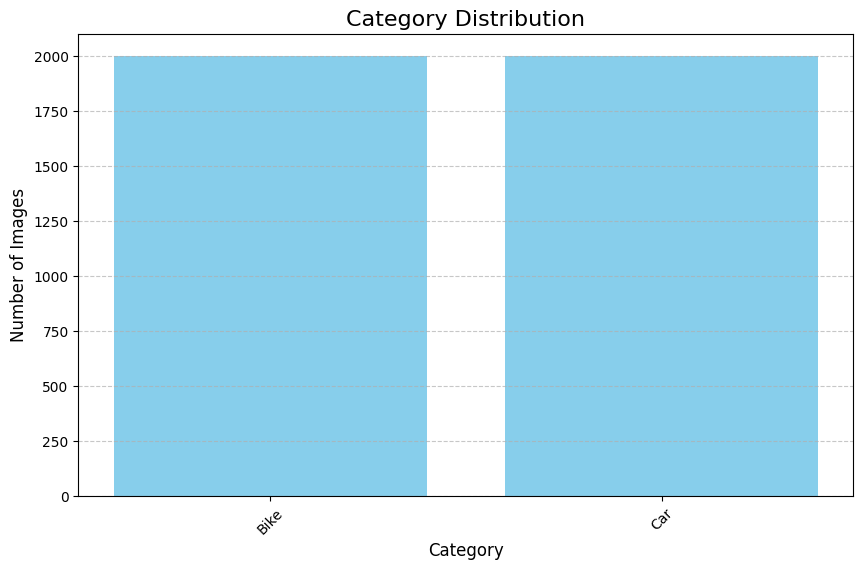

In [ ]:

dataset_path = '/content/Car-Bike-Dataset'

# menghitung jumlah file tiap kelas
category_counts = Counter()
for root, dirs, files in os.walk(dataset_path):
    category = os.path.basename(root)

    # lewati root folder (Car-Bike-Dataset)
    if category == 'Car-Bike-Dataset':
        continue

    category_counts[category] += len([file for file in files if file.endswith(('.png', '.jpg', '.jpeg'))])

print('Category Distribution:')
for category, count in category_counts.items():
    print(f'{category}: {count} images')

# membuat plot
categories = list(category_counts.keys())
counts = list(category_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(categories, counts, color='skyblue')
plt.title('Category Distribution', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Dataset terdiri atas dua kelas yaitu `Bike` dan `Car`. Setiap kelas berjumlah sebanyak 2000 gambar yang artinya data tersebut termasuk balanced data. Untuk itu, tidak perlu melalui proses data balancing.

### 3. Ukuran dan Dimensi

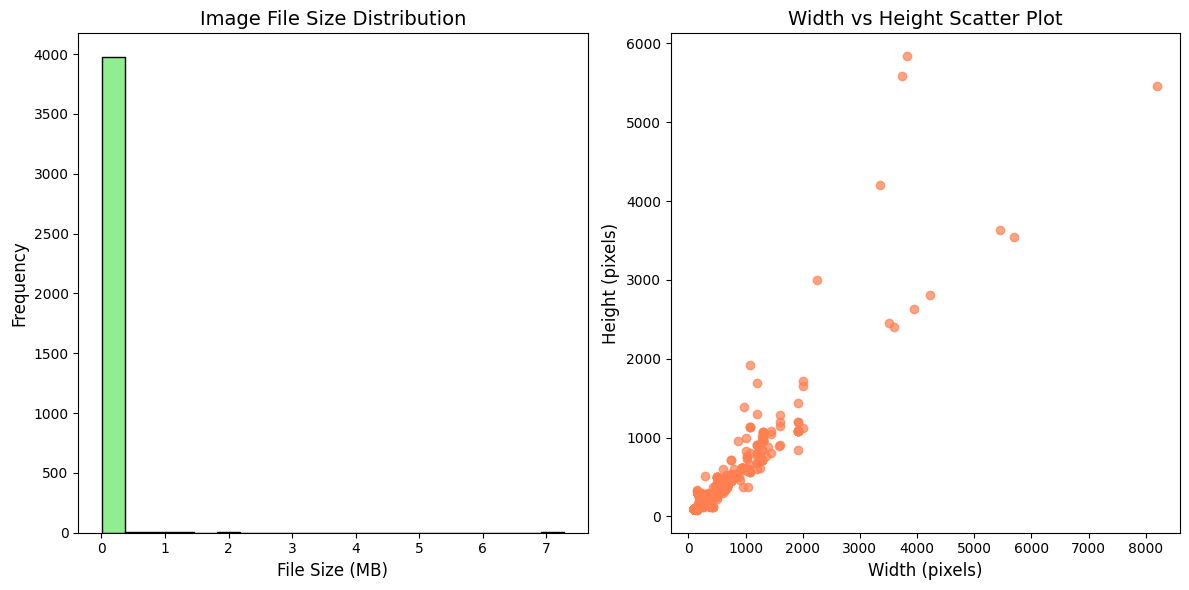

In [ ]:
dataset_path = '/content/Car-Bike-Dataset'


widths = []
heights = []
file_sizes = []

# looping dari semua data
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(root, file)

            # melihat dimensi dengan open image
            with Image.open(image_path) as img:
                width, height = img.size
                widths.append(width)
                heights.append(height)

            # menampilkan ukuran file dalam mb
            file_size = os.path.getsize(image_path) / (1024 * 1024)
            file_sizes.append(file_size)

# membuat subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# plot histogram untuk ukuran file
axes[0].hist(file_sizes, bins=20, color='lightgreen', edgecolor='black')
axes[0].set_title('Image File Size Distribution', fontsize=14)
axes[0].set_xlabel('File Size (MB)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# scatter plot untuk dimensi data
axes[1].scatter(widths, heights, color='coral', alpha=0.7)
axes[1].set_title('Width vs Height Scatter Plot', fontsize=14)
axes[1].set_xlabel('Width (pixels)', fontsize=12)
axes[1].set_ylabel('Height (pixels)', fontsize=12)

plt.tight_layout()
plt.show()

Didapati bahwa data terdiri atas ukuran dan dimensi yang berbeda-beda walaupun seperti yang paling mudah dilihat bahwa sebagian besar data berukuran dibawah 1 mb. Untuk dimensi data juga terlihat sangan variatif, bahkan ada yang sampai memiliki lebar atau tinggi pixel hingga 8000. Maka dari itu, akan dilakukan penyeragaman ukuran pixel pada proses feature engineering.

### 4. Analisis Warna (Channel)

In [ ]:
dataset_path = '/content/Car-Bike-Dataset'

# membuat list untuk file non rgb
non_rgb_files = []

# looping keseluruhan directory
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(root, file)
            with Image.open(image_path) as img:
                if img.mode != 'RGB':
                    non_rgb_files.append((file, img.mode))  # mengumpulkan list


if non_rgb_files:
    print('Non-RGB Images Found:')
    for file, mode in non_rgb_files:
        print(f'File: {file}, Mode: {mode}')
else:
    print('All images are in RGB mode.')

Non-RGB Images Found:
File: Bike (41).jpg, Mode: RGBA
File: Bike (23).png, Mode: RGBA
File: Bike (20).png, Mode: P
File: Bike (3).png, Mode: RGBA
File: Bike (27).png, Mode: P
File: Bike (8).png, Mode: RGBA
File: Bike (18).png, Mode: RGBA
File: Bike (6).png, Mode: RGBA
File: Bike (5).png, Mode: RGBA
File: Bike (25).png, Mode: RGBA
File: Bike (93).jpg, Mode: RGBA
File: Bike (22).png, Mode: P
File: Bike (24).png, Mode: RGBA
File: Bike (4).png, Mode: RGBA
File: Bike (18).jpg, Mode: RGBA
File: Bike (11).png, Mode: RGBA
File: Bike (13).png, Mode: P
File: Bike (1).png, Mode: RGBA
File: Car (1).png, Mode: P
File: Car (3).png, Mode: RGBA
File: Car (2).png, Mode: P
File: Car (6).png, Mode: RGBA
File: Car (7).png, Mode: P


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


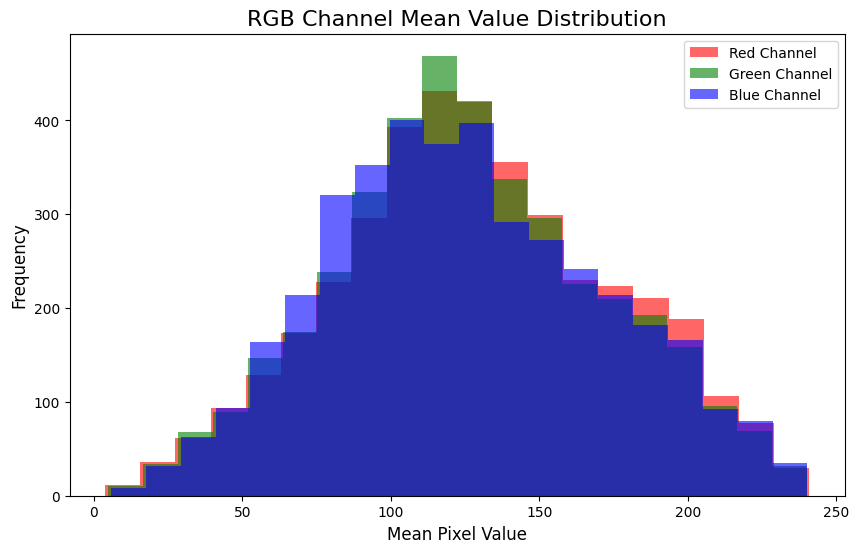

In [ ]:

dataset_path = '/content/Car-Bike-Dataset'

# membuat list
red_means = []
green_means = []
blue_means = []

# loop keseluruhan directory
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(root, file)
            with Image.open(image_path) as img:
                img = img.convert('RGB')  # memastikan image dalam rgb format

                # mengubah file ke dalam array
                img_array = np.array(img)

                # split channel
                red_channel = img_array[:, :, 0]
                green_channel = img_array[:, :, 1]
                blue_channel = img_array[:, :, 2]

                # menghitung rata-rata tiap channel
                red_means.append(np.mean(red_channel))
                green_means.append(np.mean(green_channel))
                blue_means.append(np.mean(blue_channel))

# membuat plot
plt.figure(figsize=(10, 6))

# histogram untuk red channel mean values
plt.hist(red_means, bins=20, color='red', alpha=0.6, label='Red Channel')

# histogram untuk green channel mean values
plt.hist(green_means, bins=20, color='green', alpha=0.6, label='Green Channel')

# histogram untuk blue channel mean values
plt.hist(blue_means, bins=20, color='blue', alpha=0.6, label='Blue Channel')

plt.title('RGB Channel Mean Value Distribution', fontsize=16)
plt.xlabel('Mean Pixel Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

Plot histogram dari RGB Mean Channel Value Distribution menjelaskan bahwa tone warna hijau mendominasi dalam frekuensi dengan mean pixel value yang konsisten pada angka kisaran 100-125. Sedangkan warna biru dengan wilayah yang luas menjelaskan keadaan dataset yang memiliki tone warna cool atau memiliki background seperti langit, air, dsb.

# v. Feature Engineering

In [ ]:
# membuat dataframe
bike_path = '/content/Car-Bike-Dataset/Bike/*'
car_path = '/content/Car-Bike-Dataset/Car/*'

data = []
data += [{'path':files, 'class': 'bike'} for files in glob.glob(bike_path)]
data += [{'path':files, 'class': 'car'} for files in glob.glob(car_path)]

df = pd.DataFrame(data)
df.head()

,path,class
0,/content/Car-Bike-Dataset/Bike/Bike (54).jpg,bike
1,/content/Car-Bike-Dataset/Bike/Bike (1453).jpeg,bike
2,/content/Car-Bike-Dataset/Bike/Bike (182).jpg,bike
3,/content/Car-Bike-Dataset/Bike/Bike (187).jpg,bike
4,/content/Car-Bike-Dataset/Bike/Bike (1346).jpeg,bike


Pembuatan dataframe dilakukan untuk memudahkan dalam membagi dataset menjadi train set, test set, dan validation set.

In [ ]:
# split data train, test, val

train_set, temp = train_test_split(df, test_size=0.4, stratify=df['class'], random_state= 11)
val_set, test_set = train_test_split(temp, test_size=0.5, stratify=temp['class'], random_state= 11)

print('Train Set', len(train_set))
print('Test Set', len(test_set))
print('Validation Set', len(val_set))

Train Set 2400
Test Set 800
Validation Set 800


Data dibagi menjadi 3 set menjadi train set sebanyak 2400 gambar, test set 800 gambar dan validation set 800 gambar.

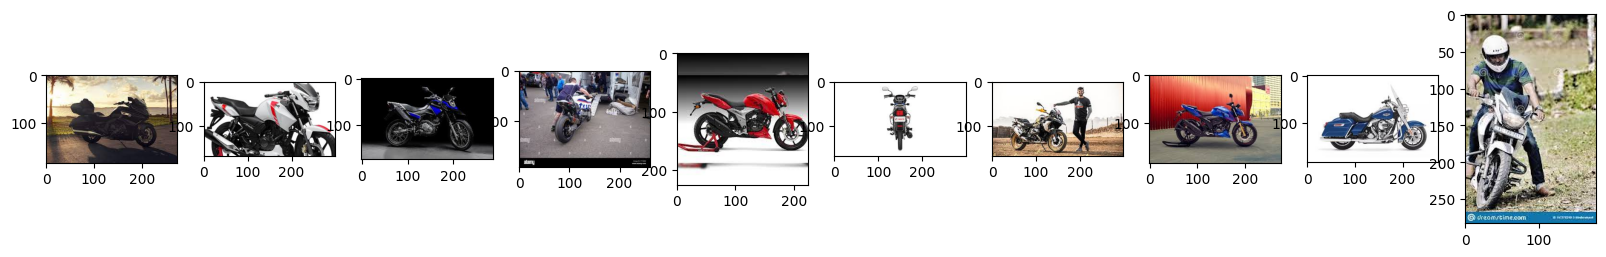

In [ ]:
# menampikan data bike
bike_images = glob.glob(bike_path)
sample_size = 10
sample_bike_image = random.sample(bike_images, sample_size)

fig, ax = plt.subplots(ncols=len(sample_bike_image), figsize=(20, 5))
for i, image_path in enumerate(sample_bike_image):
  bike = plt.imread(image_path)
  ax[i].imshow(bike)

plt.show()


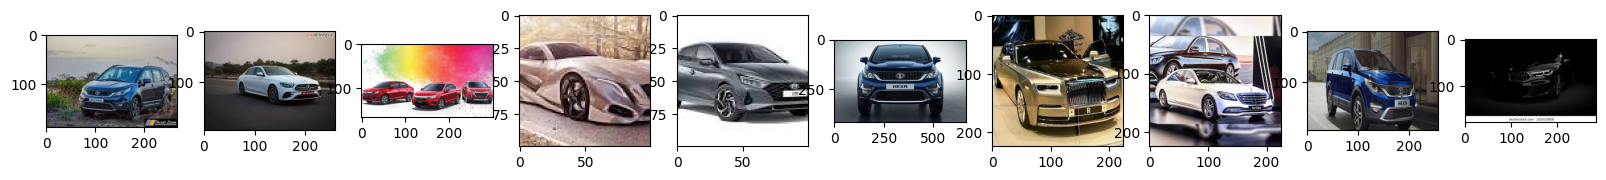

In [ ]:
# menampilkan data car
car_images = glob.glob(car_path)
sample_size = 10
sample_car_image = random.sample(car_images, sample_size)

fig, ax = plt.subplots(ncols=len(sample_car_image), figsize=(20, 5))
for i, image_path in enumerate(sample_car_image):
  car = plt.imread(image_path)
  ax[i].imshow(car)

plt.show()

Dari penelusuran yang dilakukan, terlihat dimensi yang ditampilkan dari keseluruhan gambar dari kedua kelas `Bike` dan `Car` memiliki dimensi yang berbeda-beda. Oleh sebab itu, proses feature engineering akan dilakukan menggunakan `ImageDataGenerator` untuk menyeragamkan dan membuat data augmentation untuk menambah variasi pada dataset. Data Augmentation yang dilakukan diantaranya:
- rotation_range
- horizontal_flip
- height_shift_range
- width_shift_range
- shear_range

In [ ]:
# data augmentation
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 110,
    horizontal_flip = True,
    height_shift_range = 0.25,
    width_shift_range = 0.25,
    shear_range = 40
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)
# membuat batch generator untuk train, test, dan validation set
train_set_gen = train_datagen.flow_from_dataframe(
    dataframe=train_set,
    x_col='path',
    y_col='class',
    target_size=(300,300),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
    seed=9)

val_set_gen = test_datagen.flow_from_dataframe(
    dataframe=val_set,
    x_col='path',
    y_col='class',
    target_size=(300,300),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    seed=9)

test_set_gen = test_datagen.flow_from_dataframe(
    dataframe=test_set,
    x_col='path',
    y_col='class',
    target_size=(300,300),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    seed=9)

Found 2400 validated image filenames belonging to 2 classes.
Found 800 validated image filenames belonging to 2 classes.
Found 800 validated image filenames belonging to 2 classes.


Dimensi dataset diseragamkan menjadi 300x300x3 agar memudahkan proses CNN. Lalu batch_size sebesar 32 agar agar memory tidak penuh pada saat proses training. Kemudian class_mode adalah 'binary' dikarenakan output yang diinginkan dalam bentuk binary. Pada train generator dilakukan shuffling agar  model bisa belajar lebih baik.

In [ ]:
# menampilkan value tiap kelas
print(train_set_gen.class_indices)
print(test_set_gen.class_indices)

{'bike': 0, 'car': 1}
{'bike': 0, 'car': 1}


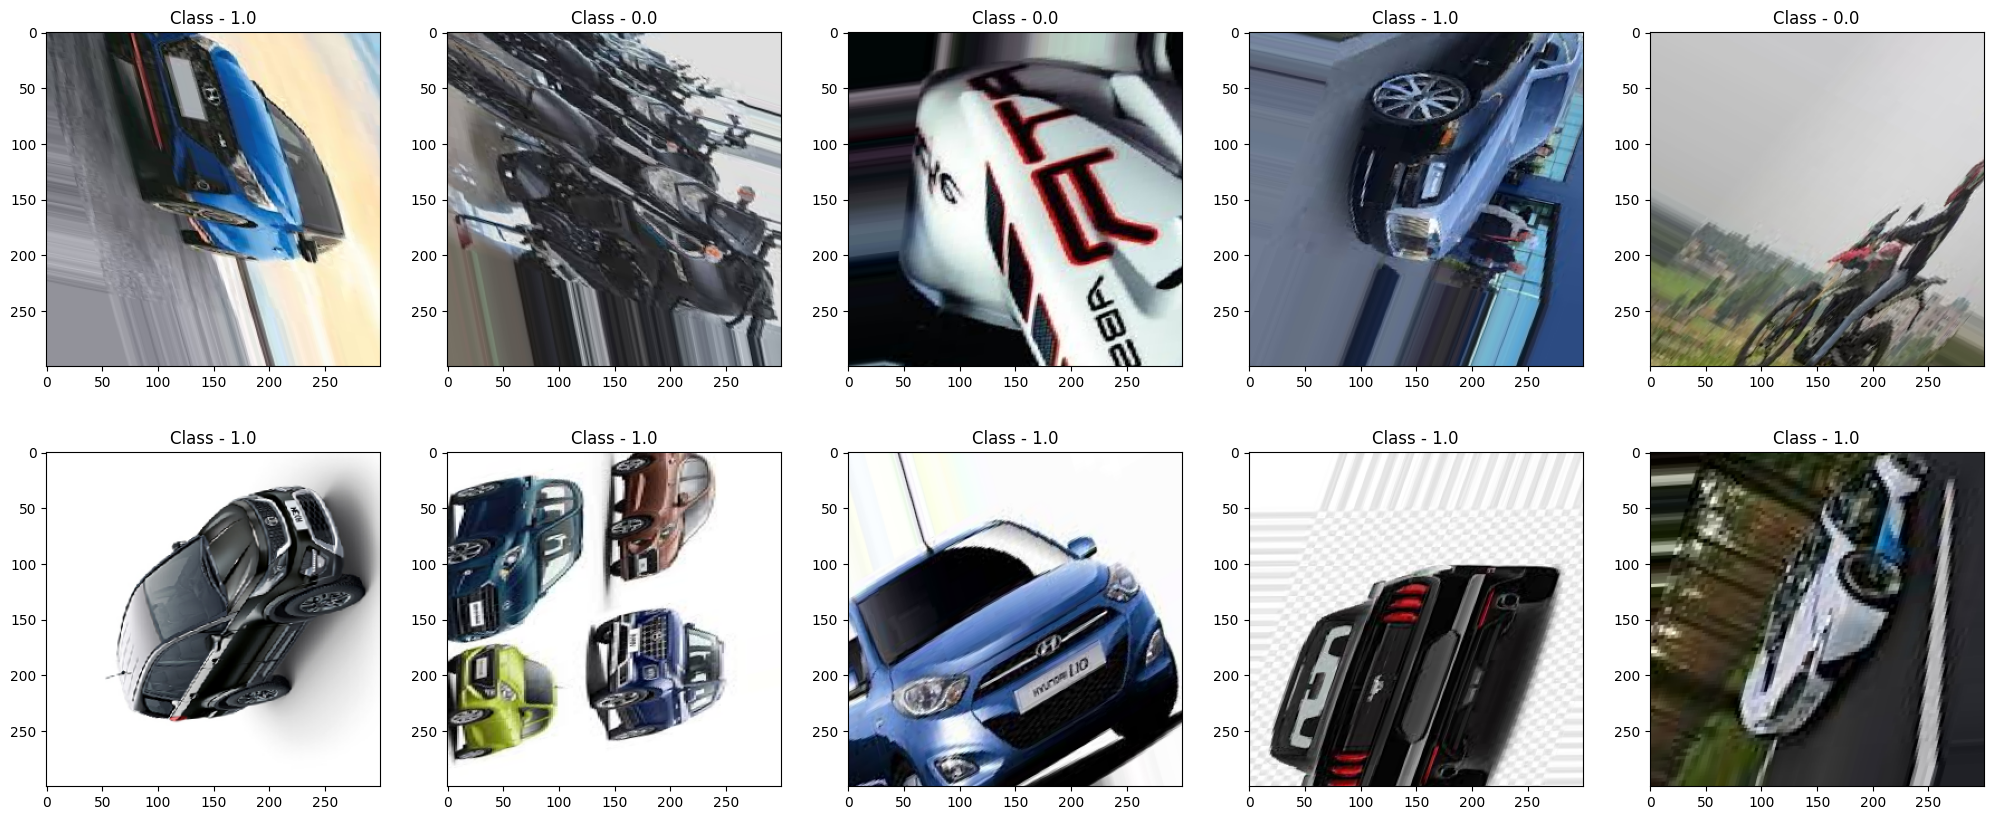

In [ ]:
# menampilkan data train set setelah data augmentation
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(25,10))
n = 0

for i in range(2):  # Loop through rows
    for j in range(5):  # Loop through columns
        img = (train_set_gen[0][0][n] * 255).astype('uint8')  # Extract n-th image
        ax[i][j].imshow(img)  # Display image
        ax[i][j].set_title(f'Class - {train_set_gen[0][1][n]}')  # Display label
        n += 1


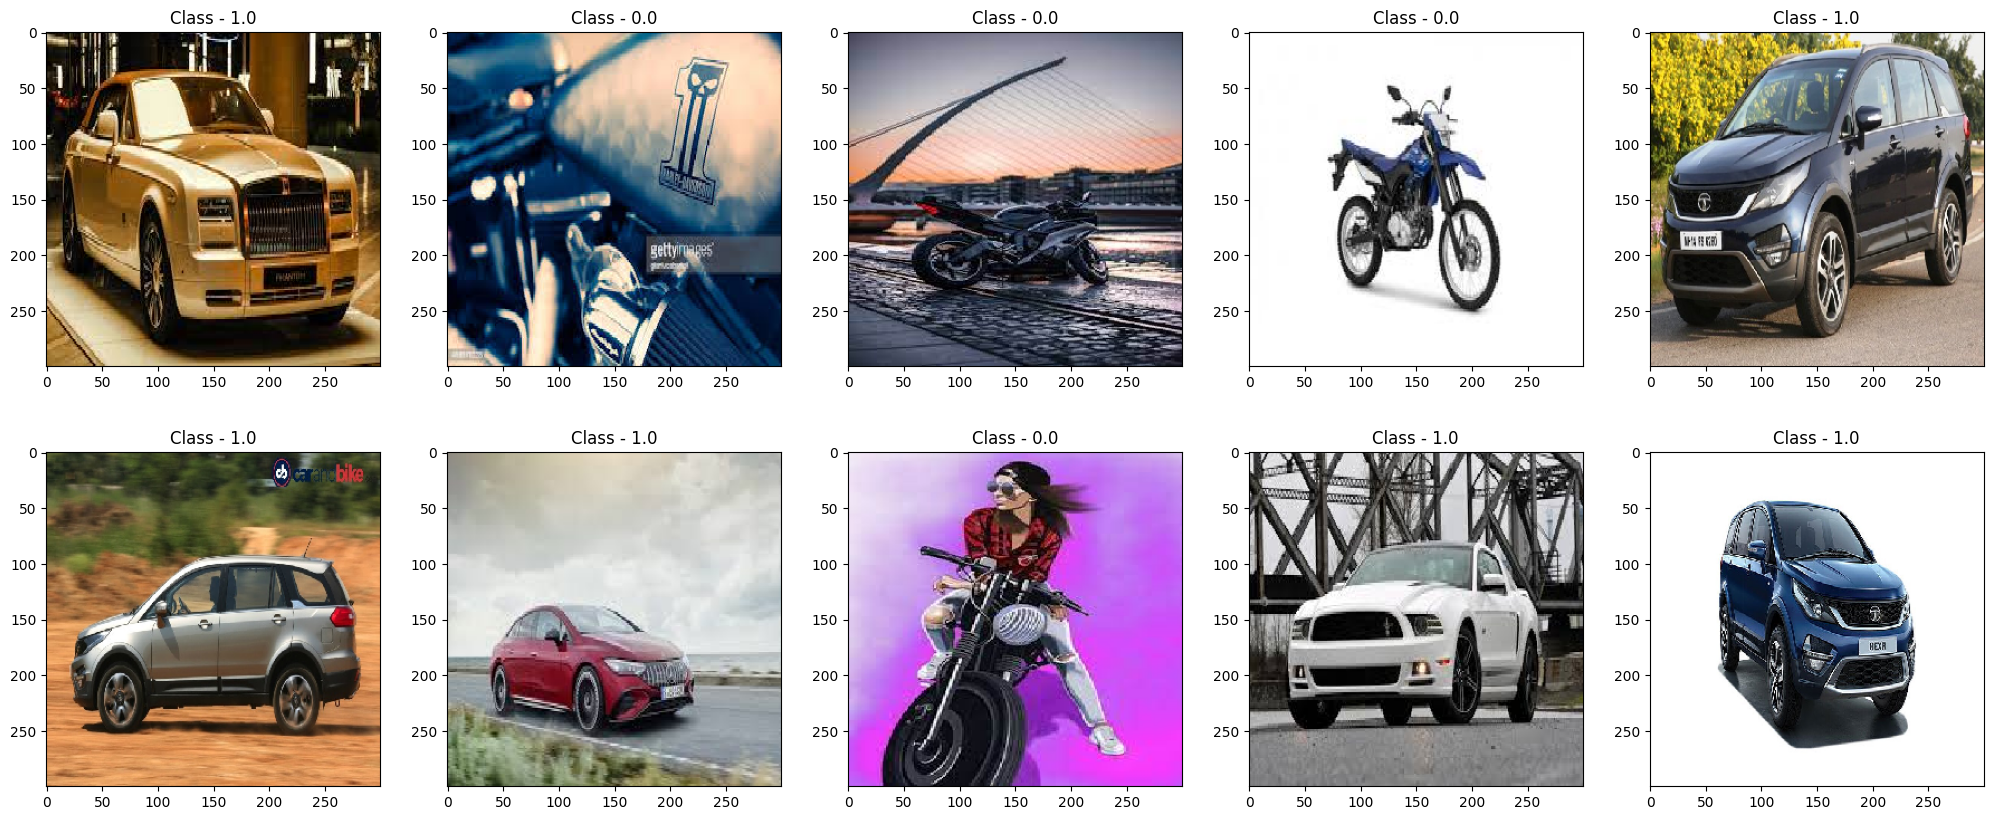

In [ ]:
# menampilkan data test set tanpa data augmentation
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(25,10))
n = 0

for i in range(2):  # Loop through rows
    for j in range(5):  # Loop through columns
        img = (test_set_gen[0][0][n] * 255).astype('uint8')  # Extract n-th image
        ax[i][j].imshow(img)  # Display image
        ax[i][j].set_title(f'Class - {test_set_gen[0][1][n]}')  # Display label
        n += 1

# vi. ANN Training (Sequential API)

## vi.1. Model Definition

In [ ]:
# clear session
seed = 11
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

ModelCheckpoint digunakan untuk menyimpan model weight dan lainya ke Google Drive dikarenkan jika menggunakan Google Colab Notebook tanpa berbayar terkadang mengalami *runtime disconnected*.

In [ ]:
# membuat model1 checkpoint
checkpoint1 = ModelCheckpoint(
    filepath='/content/drive/My Drive/GC7/model1_checkpoint.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

Model menggunakan Sequential API Model dikarenakan memiliki struktur yang lebih simpel dan praktis. Model base dinamakan model1. Pada pengaplikasiannya, model1 diber tambahan beberapa layer diantaranya Convolutional, Maxpooling, GlobalMaxPooling, Dropout, dan Dense. Penjelasan dari masing-masing layer adalah sebagai berikut:
- Convolutional Layer (32, 64, 128) artinya pada tiap layer tersebut model akan membuat filter dengan ukuran 3x3 sebanyak angka-angka tersebut. Tujuan dari layer ini adalah untuk mendeteksi spatial relationship.
- Maxpooling Layer mengurangi spatial dimension dengan ukuran pool 2x2 salah satu tujuannya untuk mencegah terjadinya overfitting.
- GlobalMaxPooling mengurangi feature map menjadi ukuran lebih kecil dengan tujuan untuk menghapus spatial dimension sementara mempertahankan fitur-fitur terkuat.
- Dropout Layer digunakan untuk mengubah neuron secara random menjadi tidak aktif sebanyak 25% pada proses training. tujuannya mengurangi overfitting dan model lebih mudah menggeneralisasi data baru.
- Dense layer pertama digunkaan untuk menyatukan fitur yang telah diekstraksi dari layer-layer sebelumnya sedangkan Dense Layer kedua digunakan sebagai output binary ditandai dengan menggunakan aktivasi 'sigmoid'.

In [ ]:
# membuat sequential api model
model1 = tf.keras.models.Sequential()

model1.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(300,300,3)))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model1.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model1.add(tf.keras.layers.Conv2D(128, (3,3), activation='relu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model1.add(tf.keras.layers.GlobalMaxPooling2D())

model1.add(tf.keras.layers.Dropout(0.25))

model1.add(tf.keras.layers.Dense(128, activation='relu'))
model1.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# compile model
model1.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 298, 298, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 149, 149, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 147, 147, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 35, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling2d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling2D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

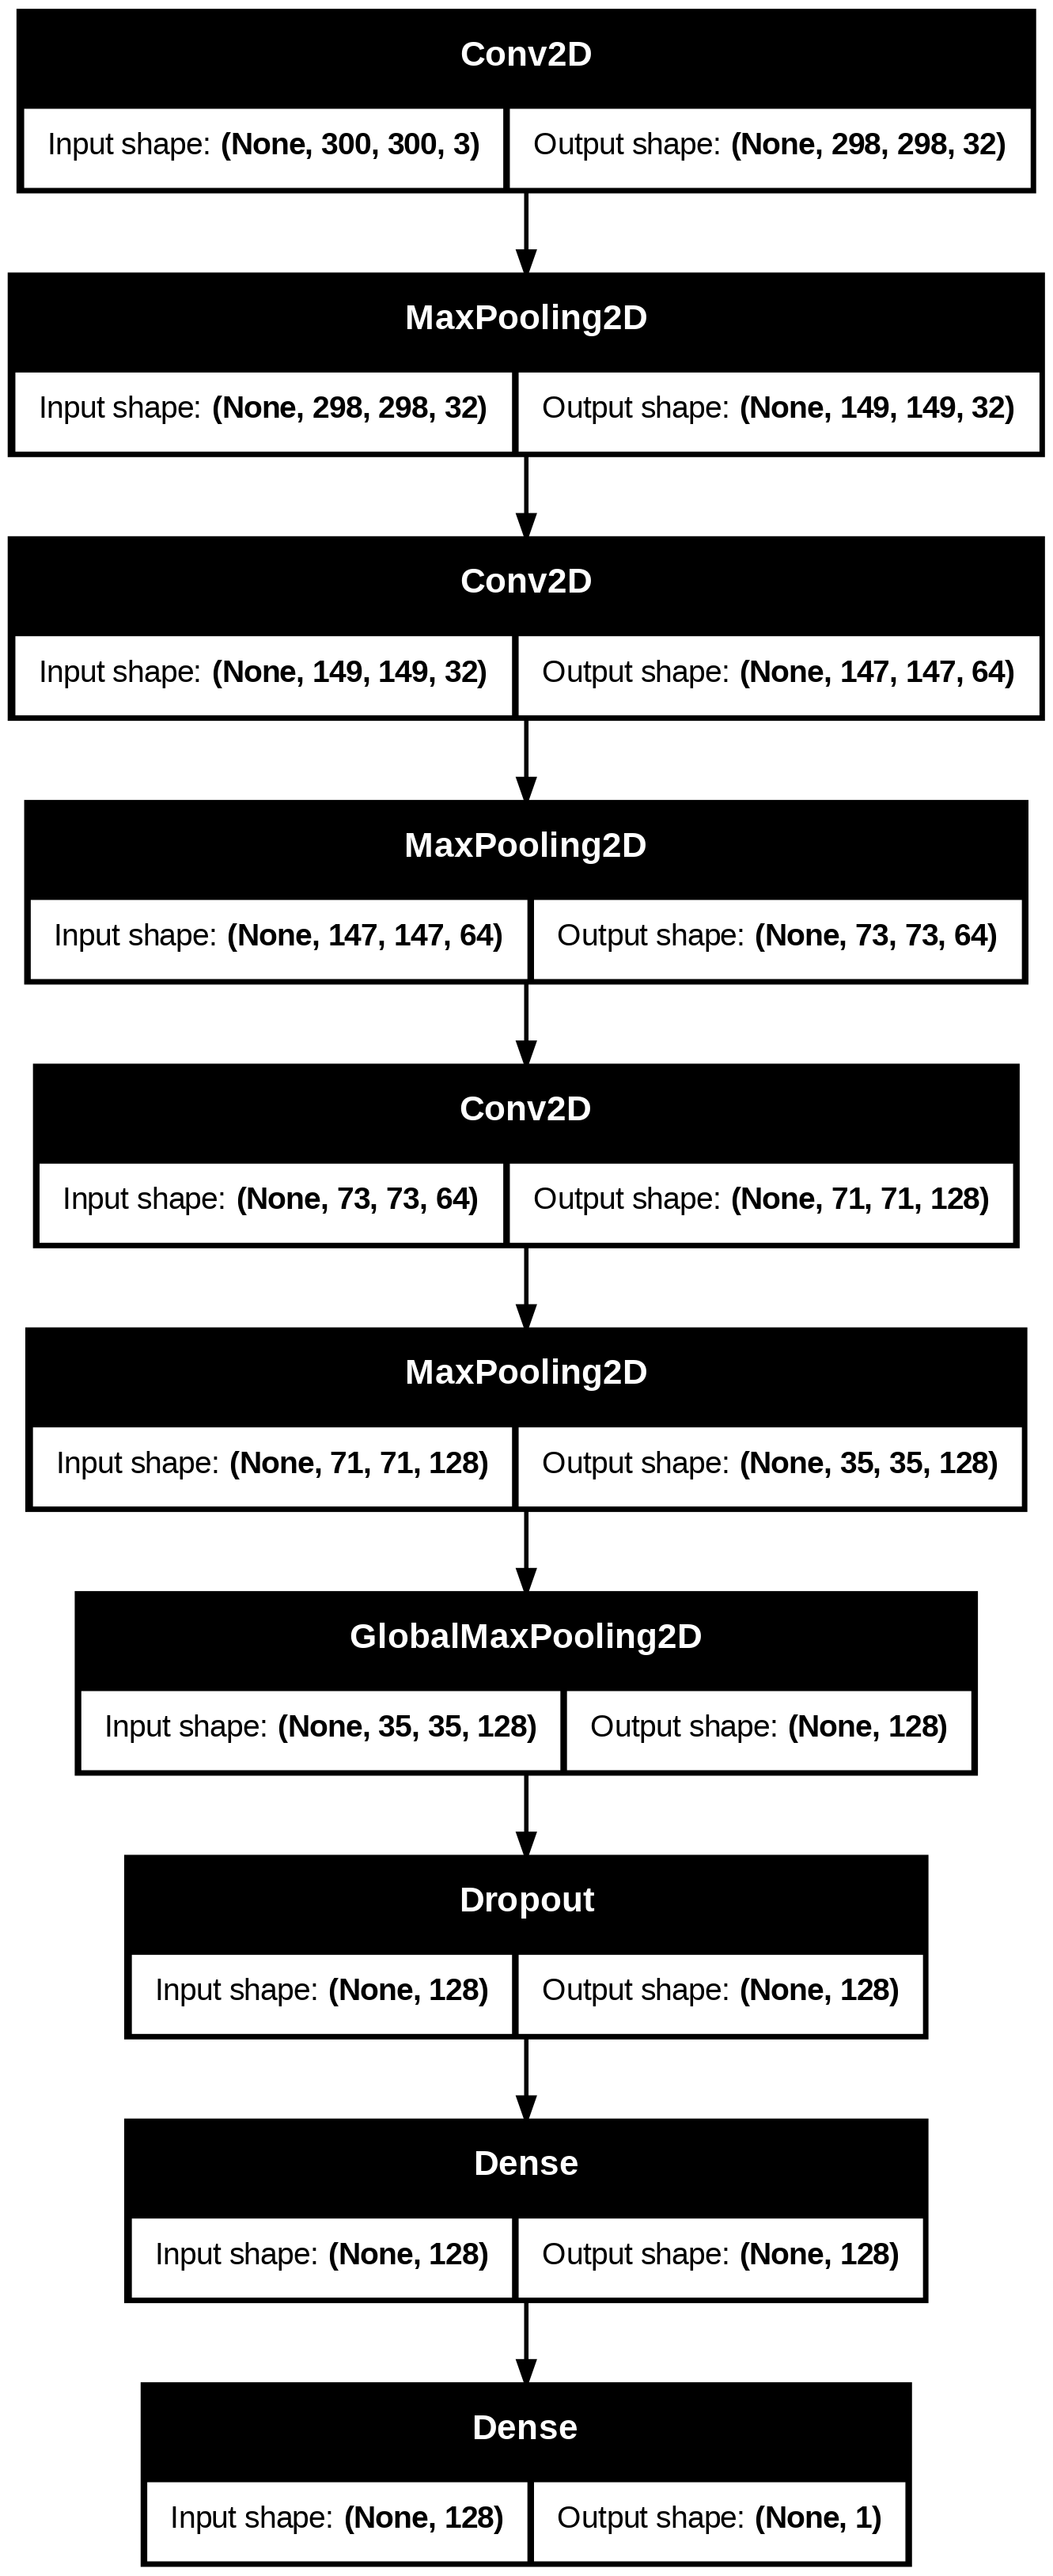

In [ ]:
# visualisasi sequential api
tf.keras.utils.plot_model(model1, show_shapes=True)

## vi.2. Model Training

Dalam melakukan model training beberapa parameter yang akan digunakan adalah sebagai berikut:
- epochs: Menentukan berapa set atau putaran model dalam melakukan training terhadap keseluruhan data train.
- steps_per_epoch: Menentukan berapa kali jumlah model melakukan training dalam satu epoch, selain itu berguna untuk mengurangi beban memory dengan membagi proses training ke dalam beberapa step. Besaran steps_per_epoch dihitung dengan cara jumlah data train/batch_size.
- validation_data digunakan untuk melihat bagaimana performa model pada data yang belum pernah terlihat.
- verbose=1: Menampilkan proses model training.
- validation_step: Berfungsi sama seperti steps_per_epoch.

In [ ]:
# model training
%%time
epoch1=25
model1_training = model1.fit(train_set_gen, epochs=epoch1, steps_per_epoch=75, validation_data=val_set_gen, verbose=1, validation_steps=25, callbacks=[checkpoint1])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
30/75 ━━━━━━━━━━━━━━━━━━━━ 30s 689ms/step - accuracy: 0.5113 - loss: 0.7061

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 67s 759ms/step - accuracy: 0.5097 - loss: 0.7005 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 73s 748ms/step - accuracy: 0.5306 - loss: 0.6890 - val_accuracy: 0.6438 - val_loss: 0.6303
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 84s 773ms/step - accuracy: 0.6137 - loss: 0.6581 - val_accuracy: 0.6538 - val_loss: 0.6433
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 768ms/step - accuracy: 0.6451 - loss: 0.6348 - val_accuracy: 0.7075 - val_loss: 0.5906
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 80s 738ms/step - accuracy: 0.6524 - loss: 0.6103 - val_accuracy: 0.7138 - val_loss: 0.5707
Epoch 6/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 55s 737ms/step - accuracy: 0.6939 - loss: 0.5778 - val_accuracy: 0.7350 - val_loss: 0.5458
Epoch 7/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 57s 748ms/step - accuracy: 0.7232 - loss: 0.5443 - val_accuracy: 0.7700 - val_loss: 0.5033
Epoch 8/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 740ms/step - accuracy: 0.7330 - loss: 0.5199 - val_accuracy: 0.675

Sekilas terlihat bahwa model1 memiliki performa yang cukup baik dengan accuracy score pada train set sebesar 84,7% dan validation sebesar 84%. Analisis selanjutnya akan menggunakan plot linear agar lebih mudah terbaca.

## vi.3. Model Evaluation

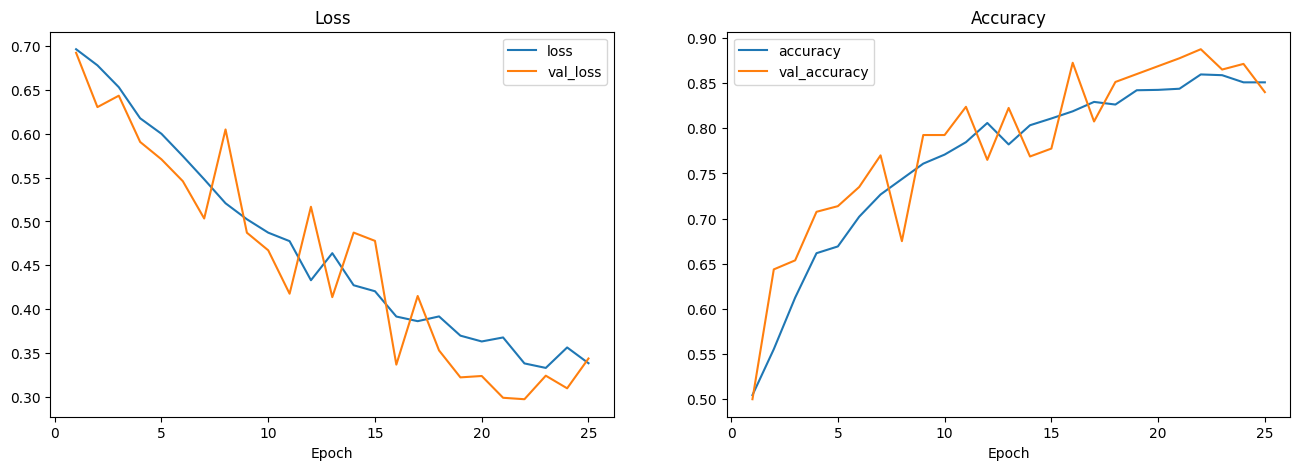

In [ ]:
# plot hasil training

fig, ax = plt.subplots(ncols=2,figsize=(16,5))
ax[0].plot(range(1, epoch1+1), model1_training.history['loss'], label='loss')
ax[0].plot(range(1, epoch1+1), model1_training.history['val_loss'], label='val_loss')
ax[0].set_title('Loss')
ax[0].legend()
ax[0].set_xlabel('Epoch')


ax[1].plot(range(1, epoch1+1), model1_training.history['accuracy'], label='accuracy')
ax[1].plot(range(1, epoch1+1), model1_training.history['val_accuracy'], label='val_accuracy')
ax[1].set_title('Accuracy')
ax[1].legend()
ax[1].set_xlabel('Epoch')


plt.show()

Setelah diketahui accuracy score berdasarkan informasi sebelumnya, pada section ini akan ditampilkan linear plot hasil dari pelatihan model tersebut. Linear plot terdiri atas plot Loss dan plot Accuracy. Dimaana kedua plot tersebut merbanding terbalik. Semakin banyak loopingn epoch yang dilakukan nilai Loss semakin berkurang dan sebaliknya nila Accuracy semakin bertambah. Selain itu, kedua plot juga menggambarkan bahwa model termasuk dalam good fit, bisa terlihat dari bagaimana hubungan antara garis biru dan jingga yang berdekatan.

In [ ]:
# evaluasi dengan test set
test_loss1, test_accuracy1 = model1.evaluate(test_set_gen, verbose=1)
print(f"Test Loss: {test_loss1}")
print(f"Test Accuracy: {test_accuracy1 * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 9/25 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.8299 - loss: 0.3871

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.8514 - loss: 0.3421
Test Loss: 0.3104232847690582
Test Accuracy: 87.00%


Pada saat dilakukan evaluasi menggunakan test set juga dapat dilihat score accuracy yang didapatkan termasuk bagus sebesar 87% dengan nilai loss yang terbilang kecil yaitu 0.31.

Untuk bab selanjutnya akan dicoba diterapkan improvisasi pada model, apakah setelah ditambahkan beberapa layer tambahan dapat meningkatkan performa model atau malah membuat performanya menjadi kurang baik.

# vii. ANN Training (Improvement)

## vii.1. Model Definition

In [ ]:
# clear session
seed = 11
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

Pada model improvement akan dilakukan uji coba dengan penambahan layer baru seperti BatchNormalization() setelah layer Convolutional. Selain itu dilakukan juga penambahan nilai Dropout menjadi 50%. Kemudian improvement dilakukan dengan menambahkan parameter early stopping yang akan dijelaskan setelah ini.

In [ ]:
# membuat sequential api model improvement
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(300,300,3)))
model2.add(tf.keras.layers.BatchNormalization())
model2.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model2.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model2.add(tf.keras.layers.BatchNormalization())
model2.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model2.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
model2.add(tf.keras.layers.BatchNormalization())
model2.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model2.add(tf.keras.layers.GlobalMaxPooling2D())

model2.add(tf.keras.layers.Dropout(0.5))

model2.add(tf.keras.layers.Dense(128, activation='relu'))
model2.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# compile model
model2.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])
model2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 298, 298, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 298, 298, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 149, 149, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 147, 147, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 147, 147, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 71, 71, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 35, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling2d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling2D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

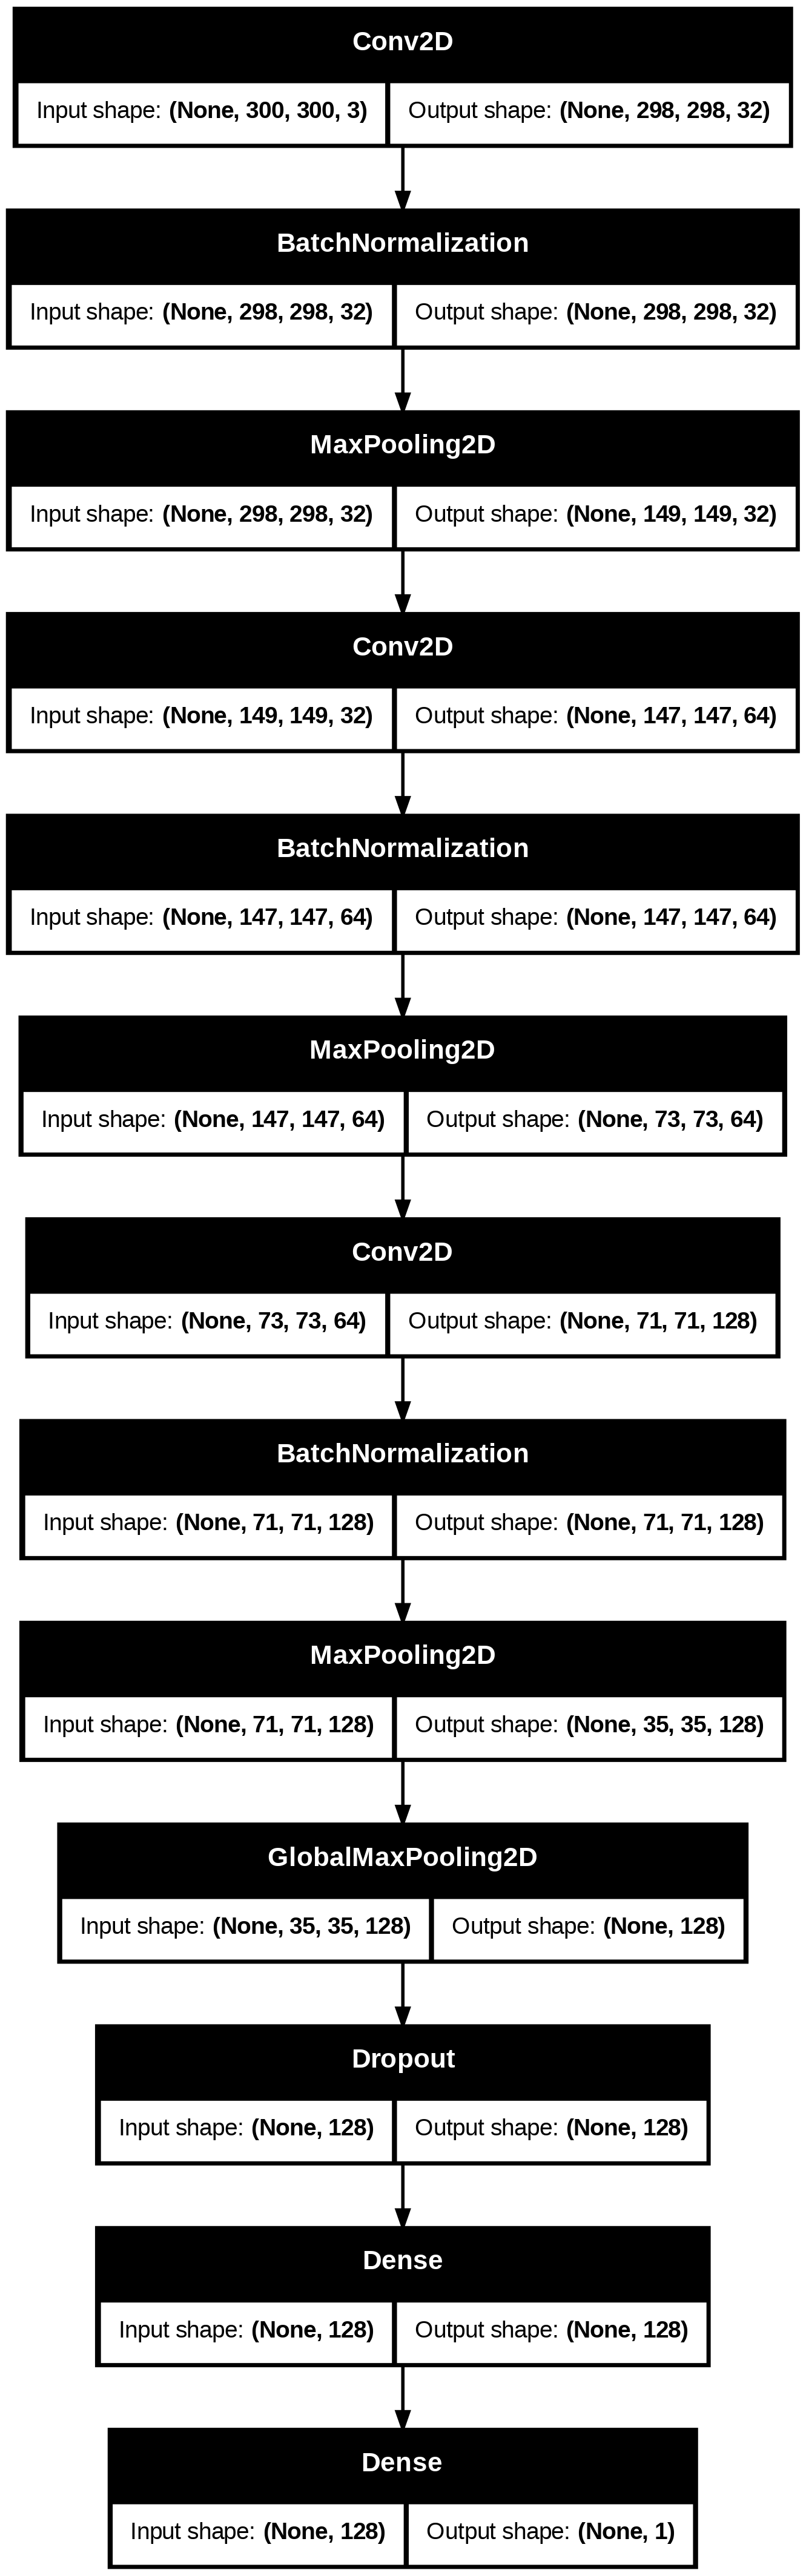

In [ ]:
tf.keras.utils.plot_model(model2, show_shapes=True)

## vii.2. Model Training

Dalam bab model improvement, saya melakukan beberapa penambahan pada layer serta menambahkan parameter callbacks. Sebelumnya saya mengikutsertakan ReduceLROnPlateu() hanya saja parameter tersebut mengakibatkan training yang sangat lambat. Pada akhirnya parameter yang saya tambahkan adalah ModelCheckpont() (sudah saya beri penjelasan) dan EarlyStopping(). EarlyStopping() sendiri bekerja dengan cara menghentikan proses training ketika model tidak memiliki perkembangan score/penurunan loss sejumlah besaran patience. Dengan demikian, EarlyStopping() diharapkan mampu untuk mengurangi resiko model training berlebihan atau overfitting.

In [ ]:
# membuat parameter callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# lr_reduce = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=5,
#     min_lr=1e-6
# )

checkpoint2 = ModelCheckpoint(
    filepath='/content/drive/My Drive/GC7/model2_checkpoint.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

In [ ]:
%%time
epoch=20
model2_training = model2.fit(train_set_gen,
                             epochs=epoch,
                             steps_per_epoch=75,
                             validation_data=val_set_gen,
                             verbose=1,
                             validation_steps=25,
                             callbacks=[early_stopping, checkpoint2])

Epoch 1/20
38/75 ━━━━━━━━━━━━━━━━━━━━ 6:35 11s/step - accuracy: 0.6734 - loss: 0.6152

KeyboardInterrupt: 

## vii.3. Model Evaluation

In [ ]:
# menampilkan hasil accuracy score
train_acc2 = model2_training.history['accuracy']
val_acc2 = model2_training.history['val_accuracy']

print(f'Train Accuracy model2: {train_acc2}')
print(f'Validation Accuracy model2: {val_acc2}')

Train Accuracy model2: [0.5375000238418579, 0.5483333468437195, 0.5408333539962769, 0.5533333420753479, 0.5520833134651184, 0.5858333110809326, 0.5899999737739563, 0.6158333420753479, 0.6166666746139526, 0.6020833253860474, 0.625, 0.606249988079071, 0.6329166889190674, 0.6433333158493042, 0.6495833396911621, 0.6454166769981384, 0.6566666960716248, 0.6625000238418579, 0.6554166674613953, 0.6670833230018616]
Validation Accuracy model2: [0.5012500286102295, 0.5824999809265137, 0.6324999928474426, 0.6274999976158142, 0.5862500071525574, 0.6512500047683716, 0.6637499928474426, 0.5587499737739563, 0.5975000262260437, 0.6175000071525574, 0.5737500190734863, 0.6487500071525574, 0.6987500190734863, 0.6662499904632568, 0.5074999928474426, 0.5575000047683716, 0.6837499737739563, 0.5662500262260437, 0.5475000143051147, 0.5774999856948853]


Meskipun sudah diberikan improvement berupa penambahan layer `BatchNormalization()`, peningkatan nilai Dropout, dan penggunakan parameter `EarlyStopping()`, sangat disayangkan performa yang dimiliki oleh model2 tidak lebih bagus bahkan semakin memburuk. Penurunan performa dapat dilihat dari accuracy score pada train set dan validation set yang menurun menjadi 66,7% dan 57,7%. Perubahan tersebut juga berdampak pada model menjadi` overfitting`. Selain itu, waktu pelaksanaan training juga terbilang sangat lambat dikarenakan penggunakan GPU yang tidak bisa diakses akibat limit dari Colab Notebook.

In [ ]:
print(len(model2_training.history['loss']))

20


In [ ]:
epch = range(1, len(model2_training.history['loss']) + 1)

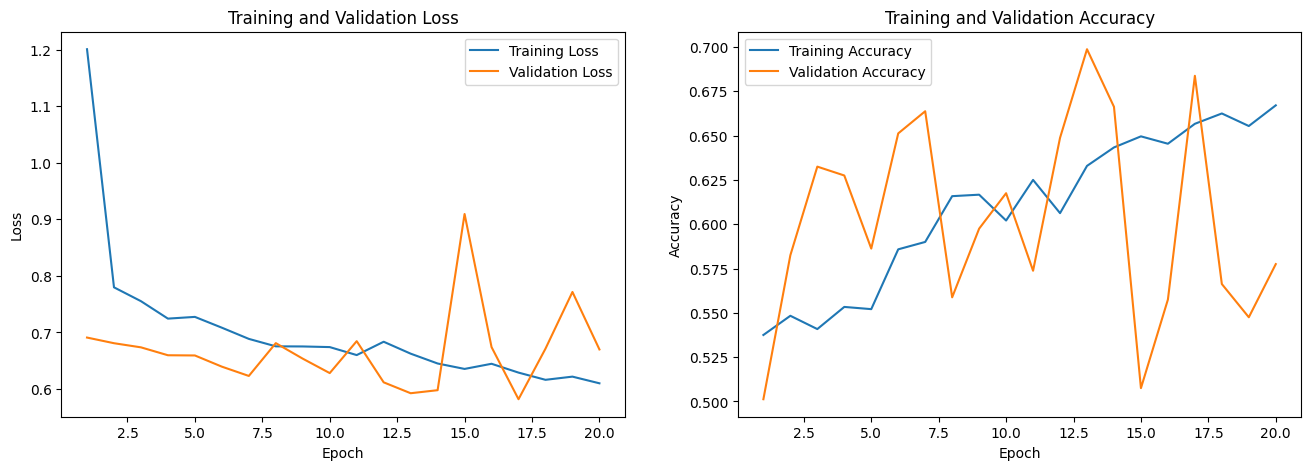

In [ ]:
# visualisasi hasil model training
fig, ax = plt.subplots(ncols=2, figsize=(16, 5))

# plot loss
ax[0].plot(epch, model2_training.history['loss'], label='Training Loss')
ax[0].plot(epch, model2_training.history.get('val_loss', []), label='Validation Loss')
ax[0].set_title('Training and Validation Loss')
ax[0].legend()
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

# plot accuracy
ax[1].plot(epch, model2_training.history['accuracy'], label='Training Accuracy')
ax[1].plot(epch, model2_training.history.get('val_accuracy', []), label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

plt.show()

Dalam grafik diatas, performa model lebih mudah untuk dimengerti. Pada plot Loss, meamng terlihat saat epoch ke 20, training loss dan validation loss memiliki akhir yang berdekatan. Namun demikian, overfitting dapat juga diketahui dari plot Accuracy dimana traning dan validation accuracy memiliki gap yang cukup jauh, dengan nilai training accuracy lebih baik.

In [ ]:
# evaluasi dengan test set
test_loss2, test_accuracy2 = model2.evaluate(test_set_gen, verbose=1)
print(f"Test Loss: {test_loss2}")
print(f"Test Accuracy: {test_accuracy2 * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 6/25 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.6617 - loss: 0.5736

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6740 - loss: 0.5815
Test Loss: 0.5778629779815674
Test Accuracy: 68.62%


Sedangkan jika dibandingkan dengtan test accuracy, model bisa dikategorikan sebagai `goodfit`. Walaupun accuracy score pada train set hanya sebesar 66,7% dan test set 68,6%.

# viii. Model Saving

Karena saya melihat penurunan performa pada model improvement (model2), maka dari itu saya berinisiatif untuk menyimpan model improvement beserta model base (model1) yang memiliki performa lebih baik. Kemudian file model tersebut disimpan dalam bentuk zip untuk menurunkan ukuran.

In [ ]:
# menyimpan model1 ke google drive
model1.save("/content/drive/My Drive/GC7/bike_and_car_model1.keras")

In [ ]:
!zip -r "/content/drive/My Drive/GC7/bike_and_car_model1.zip" "/content/drive/My Drive/GC7/bike_and_car_model1.keras"

  adding: content/drive/My Drive/GC7/bike_and_car_model1.keras (deflated 15%)


In [ ]:
# menyimpan model1 ke google drive
model2.save("/content/drive/My Drive/GC7/bike_and_car_model2.keras")

In [ ]:
!zip -r "/content/drive/My Drive/GC7/bike_and_car_model2.zip" "/content/drive/My Drive/GC7/bike_and_car_model2.keras"

  adding: content/drive/My Drive/GC7/bike_and_car_model2.keras (deflated 11%)


Sebetulnya, sebelum saya melakukan model saving menggunakan syntax `save()`, saya telah mengaplikasikan parameter `callbacks=[ModelCheckpoint]` pada kedua model di atas. Parameter tersebut berguna untuk menyimpan performa model terbaik pada keseluruhan epoch.` ModelCheckpoint()` juga berfungsi sebagai solusi untuk mencegah kesalahan pada saat training yang menyebabkan proses training terputus di tengah jalan atau runtime disconnected.

# ix. Model Inference

Model Inference dilakukan pada Notebook lainnya dengan nama `model_inf.ipynb`

# x. Conclusion

Secara keseluruhan, proses pembuatan model Convolutional Neural Network untuk Computer Vision berjalan dengan baik. Dimulai dari mengambil data dari source hingga melakukan prediksi data inference. Namun, terdapat beberapa kendala pada saat melakukan model training. Masalah utama adalah waktu training yang sangat lambat disebabkan oleh penggunakan GPU yang terbatas di Google Colab Notebook versi gratis. Hal tersebut selain menyebabkan menghabiskan waktu yang panjang untuk masuk proses selanjutnya. Selain itu, karena proses training yang memakan waktu lama tersebut membuat Model Improvement tidak optimal. Pada akhirnya model improvement malah memiliki score yang lebih buruk dibandingkan Base Model.

Karena saya merasa Base Model memiliki kemampuan dalam melakukan prediksi lebih baik dengan train accuracy score mencapai 84,7% dan validation accuracy score 84%. Selain itu, karena penggunaan ModelCheckpoint mengakibatkan saya bisa menyimpan model terbaik saat melakukan training yang pada akhirnya model tersebutlah yang saya gunakan untuk data inference dimana model tersebut mampu memprediksi dengan benar 5 dari 6 data gambar baru. Model tersebut juga saya simpan dengan folder yang sama dengan model lainnya di Google Drive.

Meskipun semua proses pada project ini berjalan dengan lancar, masih terdapat hal-hal yang bisa ditingkatkan lagi. Pertama adalah pada saat feature engineering bisa dilakukan penyeragaman pada tipe file menjadi .jpg. Selain itu, penyeragaman juga bisa dilakukan pada channel warna menjadi RGB. Kedua adalah menambahkan data gambar lebih banyak untuk kategori Bike dan Car agar model lebih baik lagi dalam belajar. Yang terakhir adalah dilakukan percobaan ulang pada model improvement dengan penambahan layer baru, penambahan jumlah filter, penambahan parameter baru seperti padding, penyesuaian pada learning rate, dan lainnya.

URL [Model](https://drive.google.com/drive/folders/1cD5YXnsDM5h51ZcXKgItThOTkNpLklv8?usp=drive_link) pada Google Drive